In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

| Variable  | Definition                              | Key                                   |
|-----------|------------------------------------------|---------------------------------------|
| survival  | Survival                                 | 0 = No, 1 = Yes                      |
| pclass    | Ticket class                             | 1 = 1st, 2 = 2nd, 3 = 3rd           |
| sex       | Sex                                      | -                                     |
| age       | Age in years                             | -                                     |
| sibsp     | # of siblings / spouses aboard Titanic   | -                                     |
| parch     | # of parents / children aboard Titanic   | -                                     |
| ticket    | Ticket number                            | -                                     |
| fare      | Passenger fare                           | -                                     |
| cabin     | Cabin number                             | -                                     |
| embarked  | Port of Embarkation                      | C = Cherbourg, Q = Queenstown, S = Southampton |

# Starting with EDA

Understanding the data, rather than making graphs.

- Shape
- Info
- Describe
- Then a glimpse of data in terms of head and tail

In [5]:
df.shape

(891, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [19]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Categorize data in numerical or strings

Basically it can scale or can only have distinct values

In [10]:
# Numerical columns (int + float)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(list(numerical_cols))


# Categorical / string columns
categorical_cols = df.select_dtypes(include=['str']).columns

print("\nCategorical Columns:")
print(list(categorical_cols))

Numerical Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Text(0.5, 1.0, 'Age Distribution')

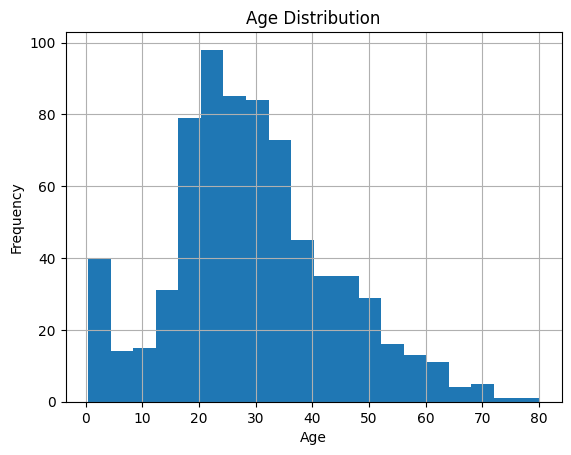

In [15]:
# Graph over Ages to see distributon

df['Age'].hist(bins=20)

plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")

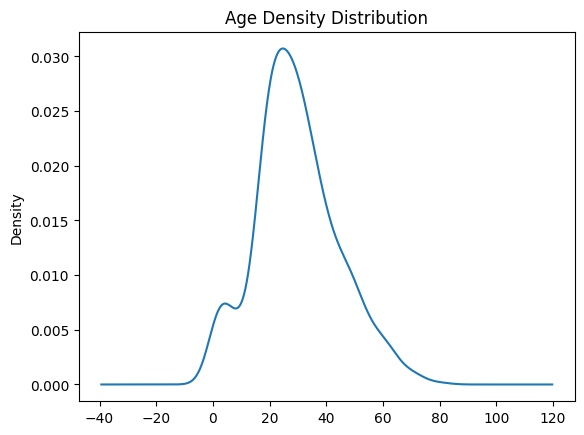

In [17]:
df['Age'].plot(kind='kde')
plt.title("Age Density Distribution")
plt.show()

In [ ]:
def _handling_missing_data(df):

    # Cabin cant be dropped, or ignored.
    # It shows if the person had cabin or not, so we categorize it as 0 or 1
    df["HasCabin"] = df["Cabin"].notnull().astype(int)
    df.drop(columns=["Cabin"], inplace=True)

    # Filling ages with median for now
    df["Age"].fillna(df["Age"].median(), inplace=True)

    # Categorical, so fill with mode -> only 2 msising, doesn't impact the data
    df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

    return df

In [ ]:
df = _handling_missing_data(df)
test_df = _handling_missing_data(test_df)

Numerical Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

In [ ]:
from sklearn.ensemble import RandomForestClassifier

y = df["Survived"]

features = ["PassengerID", "Pclass", "Age", "SibSp", "Parch", "Fare", "Sex", "Ticket", "HasCabin", "Embarked"]
X = pd.get_dummies(df[features])
X_test = pd.get_dummies(test_df[features])

X_test = X_test.reindex(columns=X.columns, fill_value=0)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X, y)
predictions = model.predict(X_test)

output = pd.DataFrame({'PassengerId': test_df.PassengerId, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Your submission was successfully saved!")
